# Five-player Cournot game: parameter-evolving DTB

A simplified copy of [the singular-game notebook](https://github.com/sun-mengwei/dtb-colab-experiments/blob/codex/game-dynamics-dtb/DTB_Game_Ver2/singular_game_2d_parameter_evolving_dtb.ipynb), using its parameter-evolving neural-map update with periodic NN refitting and tangent-basis refresh for one deterministic five-player example.

With $b=2$, $\mu=7/4$, and $s_i=\sum_{j\ne i}x_j$, the game velocity is

$$F_i(x)=2b\left(\max\{\mu s_i(1-s_i),0\}-x_i\right).$$

Initial particles are uniform on $[0,1]^5$. Run all cells to display the point clouds in $(x_1,x_2)$, $(x_2,x_3)$, $(x_3,x_4)$, and $(x_4,x_5)$, followed by the tangent-projection error over time.

[Open in Colab](https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/codex%2Fgame-dynamics-dtb/DTB_Game_Ver2/cournot_5d_b2_mu7_4_parameter_evolving_dtb.ipynb)

In [6]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

# Use the existing helpers locally, or obtain them when running in Colab.
module_files = ('dtb.py', 'run_game_dtb.py')
module_dir = next((p for p in (Path.cwd(), Path.cwd() / 'DTB_Game_Ver2')
                   if all((p / name).is_file() for name in module_files)), None)
if module_dir is None:
    if not Path('/content').is_dir():
        raise FileNotFoundError('Run from the repository root or DTB_Game_Ver2.')
    repo = Path('/content/dtb-colab-experiments')
    if not repo.exists():
        subprocess.run([
            'git', 'clone', '--depth', '1', '--branch', 'codex/game-dynamics-dtb',
            'https://github.com/sun-mengwei/dtb-colab-experiments.git', str(repo),
        ], check=True)
    module_dir = repo / 'DTB_Game_Ver2'
sys.path.insert(0, str(module_dir.resolve()))

from dtb import flat_params, write_flat_into_model
from run_game_dtb import ResidualMLPMap, game_dtb_basis_matrices, map_at

## Parameters

The map is a residual tanh MLP, initially equal to the identity. Every 100 time steps, refit a perturbed copy of the NN to the current map and draw a new subset of 128 parameter coordinates for the tangent basis. Set `REFIT_EVERY = 0` to disable refitting.

In [7]:
SEED = 0
DIM = 5
COURNOT_B = 2.0
COURNOT_MU = 7 / 4
N_PARTICLES = 2000

H = 0.001
T_FINAL = 2.0
SNAPSHOT_TIMES = (0.0, 0.25, 0.5, T_FINAL)
WIDTH, DEPTH = 16, 2
BASIS_SIZE = 128
RIDGE = 1e-6
JACOBIAN_CHUNK = 256
REFIT_EVERY = 100
REFIT_MAX_ITER = 500
REFIT_PERTURB = 0.01  # Parameter perturbation before fitting back to the map.
REFIT_TOL = 1e-3  # Maximum RMS map discrepancy on the fixed labels.

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE = torch.float64
torch.set_num_threads(min(4, torch.get_num_threads()))


def game_velocity(x):
    rivals = x.sum(dim=-1, keepdim=True) - x
    best_response = (COURNOT_MU * rivals * (1 - rivals)).clamp_min(0.0)
    return 2 * COURNOT_B * (best_response - x)

## Evolve the map

Keep the initial labels $z_n$ fixed and set $x_n(t)=T_{\theta(t)}(z_n)$. At each step, recompute the selected-parameter Jacobian $J$ and solve

$$\alpha=\arg\min_a\frac1N\sum_n\|J_na-F(x_n)\|_2^2+\eta\|a\|_2^2,
\qquad \theta_{\mathrm{selected}}\leftarrow\theta_{\mathrm{selected}}+h\alpha.$$

As in the source notebook, the ridge solve uses an SVD with $\eta=10^{-6}$. The plotted projection error is the empirical RMS velocity residual

$$e_{\mathrm{proj}}(t)=\sqrt{\frac1N\sum_n\|J_n\alpha-F(x_n)\|_2^2}.$$

This measures the regularized tangent fit at the current cloud, not an error against an exact particle trajectory. Every stored cloud is evaluated from the updated nonlinear map.

At each refit, freeze the current targets $X_k(z_n)=T_{\theta_k}(z_n)$ and initialize a new NN from a small random perturbation of the current parameters and train **all its parameters** by minimizing $N^{-1}\sum_n\|T_{\vartheta}(z_n)-X_k(z_n)\|_2^2$. The original labels $z_n$ stay fixed. Accept the fit only when its RMS map discrepancy is at most `REFIT_TOL`; then flatten the new parameters, draw new parameter coordinates, and recompute their Jacobian. Refitting uses no physical time and introduces a bounded fitting error on these labels. There is no refit at the final time. Dotted lines on the error plot mark the refits.
Starting near the current parameters keeps the refit accurate. The perturbation gives refitting a nonzero initial loss.


In [8]:
def refit_map(theta, model, structure, z):
    # Read X_k from the evolved flat parameters, not the model's old weights.
    target_map = map_at(theta, z, model, structure).detach()
    fitted = ResidualMLPMap(dim=DIM, width=WIDTH, depth=DEPTH,
                            activation='tanh', dtype=DTYPE).to(DEVICE)
    write_flat_into_model(fitted, theta, structure)
    with torch.no_grad():
        for parameter in fitted.parameters():
            parameter.add_(REFIT_PERTURB * torch.randn_like(parameter))
    optimizer = torch.optim.LBFGS(
        fitted.parameters(), max_iter=REFIT_MAX_ITER, history_size=50,
        tolerance_grad=1e-10, tolerance_change=1e-12, line_search_fn='strong_wolfe')

    def closure():
        optimizer.zero_grad(set_to_none=True)
        loss = (fitted(z) - target_map).square().sum(dim=1).mean()
        loss.backward()
        return loss

    optimizer.step(closure)
    with torch.no_grad():
        error = (fitted(z) - target_map).square().sum(dim=1).mean().sqrt()
    if not torch.isfinite(error) or error.item() > REFIT_TOL:
        raise RuntimeError(f'Refit RMS error {error.item():.3g} exceeds {REFIT_TOL:g}; '
                           'increase REFIT_MAX_ITER.')
    new_theta, new_structure, _ = flat_params(fitted)
    return fitted, new_theta, new_structure


def draw_basis(theta):
    indices = torch.randperm(theta.numel(), generator=basis_generator)
    return indices[:BASIS_SIZE].sort().values.to(DEVICE)


# Rerunning this cell starts the same single experiment from scratch.
torch.manual_seed(SEED)
basis_generator = torch.Generator().manual_seed(SEED + 1)
z = torch.rand(N_PARTICLES, DIM, generator=torch.Generator().manual_seed(SEED),
               dtype=DTYPE).to(DEVICE)
model = ResidualMLPMap(dim=DIM, width=WIDTH, depth=DEPTH,
                       activation='tanh', dtype=DTYPE).to(DEVICE)
theta, structure, _ = flat_params(model)
selected = draw_basis(theta)

snapshot_times = np.unique(np.round(SNAPSHOT_TIMES, 12))
times = np.unique(np.round(np.r_[np.arange(0, T_FINAL, H), snapshot_times, T_FINAL], 12))
projection_error, refit_times = [], []
clouds = {}

for k, t in enumerate(times):
    if REFIT_EVERY and 0 < k < len(times) - 1 and k % REFIT_EVERY == 0:
        model, theta, structure = refit_map(theta, model, structure, z)
        selected = draw_basis(theta)
        refit_times.append(float(t))

    x, _, J_flat = game_dtb_basis_matrices(
        theta, selected, z, model, structure, chunk=JACOBIAN_CHUNK)
    x, J_flat = x.detach(), J_flat.detach()
    velocity = game_velocity(x)

    A = J_flat / np.sqrt(N_PARTICLES)
    target = velocity.reshape(-1) / np.sqrt(N_PARTICLES)
    U, s, Vh = torch.linalg.svd(A, full_matrices=False)
    alpha = Vh.T @ ((s / (s.square() + RIDGE)) * (U.T @ target))
    error = torch.linalg.vector_norm(A @ alpha - target)
    if not torch.isfinite(error) or not torch.isfinite(alpha).all():
        raise FloatingPointError(f'Nonfinite DTB update at t={t:g}.')
    projection_error.append(error.item())

    if t in snapshot_times:
        clouds[float(t)] = x.cpu().numpy().copy()
    if k + 1 < len(times):
        theta[selected] += float(times[k + 1] - t) * alpha

write_flat_into_model(model, theta, structure)
projection_error = np.asarray(projection_error)

## Point-cloud projections

Rows show the four adjacent coordinate pairs; columns show physical time. All particles are displayed, with common axis limits across the figure.

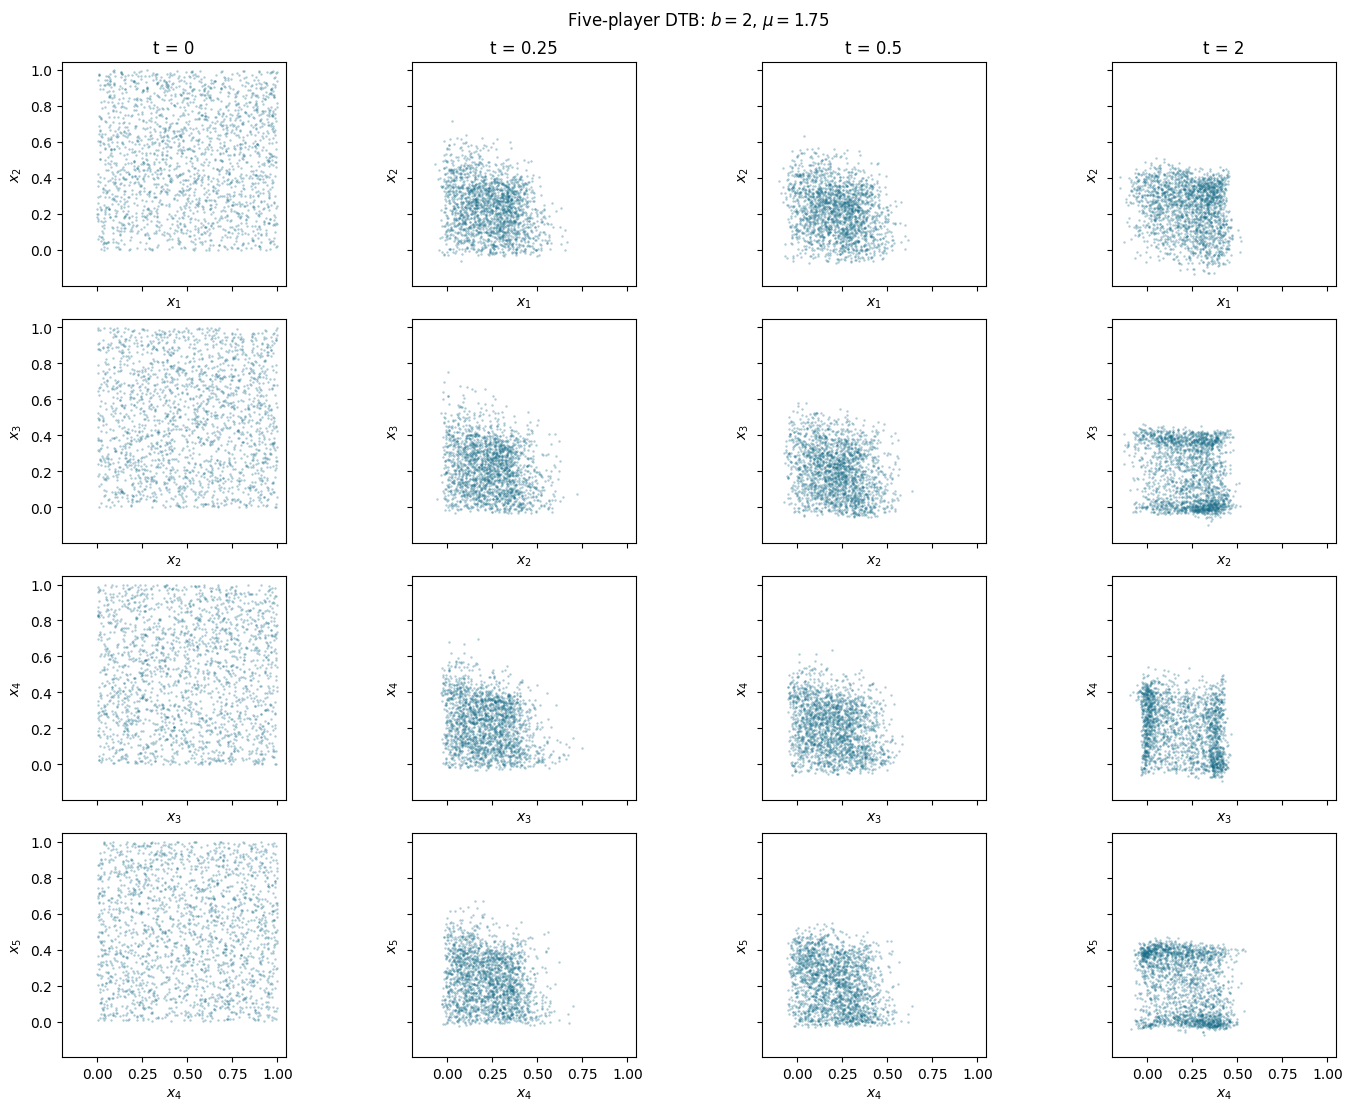

In [9]:
pairs = ((0, 1), (1, 2), (2, 3), (3, 4))
fig, axes = plt.subplots(4, len(clouds), figsize=(3.5 * len(clouds), 11),
                         sharex=True, sharey=True, squeeze=False, layout='constrained')
lo = min(points.min() for points in clouds.values())
hi = max(points.max() for points in clouds.values())
padding = 0.04 * max(hi - lo, 1e-6)

for row, (i, j) in enumerate(pairs):
    for col, (t, points) in enumerate(clouds.items()):
        ax = axes[row, col]
        ax.scatter(points[:, i], points[:, j], s=3, alpha=0.35,
                   color='#176b87', linewidths=0, rasterized=True)
        ax.set(xlabel=fr'$x_{i + 1}$', ylabel=fr'$x_{j + 1}$',
               xlim=(lo - padding, hi + padding), ylim=(lo - padding, hi + padding))
        ax.set_aspect('equal', adjustable='box')
        if row == 0:
            ax.set_title(f't = {t:g}')
fig.suptitle(fr'Five-player DTB: $b={COURNOT_B:g}$, $\mu={COURNOT_MU:g}$')
plt.show()

## Projection-error trajectory

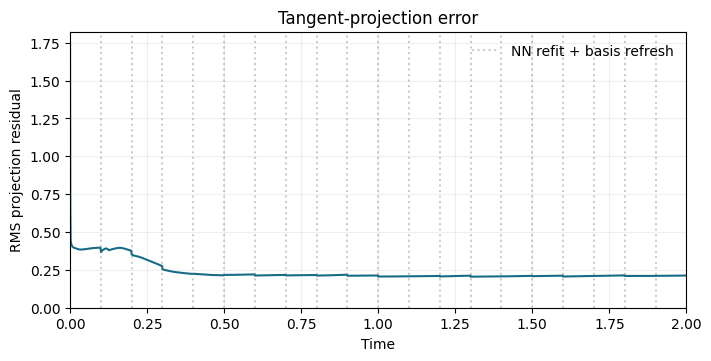

In [10]:
fig, ax = plt.subplots(figsize=(7, 3.5), layout='constrained')
ax.plot(times, projection_error, color='#176b87', linewidth=1.5)
for index, t in enumerate(refit_times):
    ax.axvline(t, color='0.5', linestyle=':', alpha=0.4,
               label='NN refit + basis refresh' if index == 0 else None)
if refit_times:
    ax.legend(frameon=False)
ax.set(xlabel='Time', ylabel='RMS projection residual',
       title='Tangent-projection error', xlim=(0, T_FINAL), ylim=(0, None))
ax.grid(alpha=0.2)
plt.show()